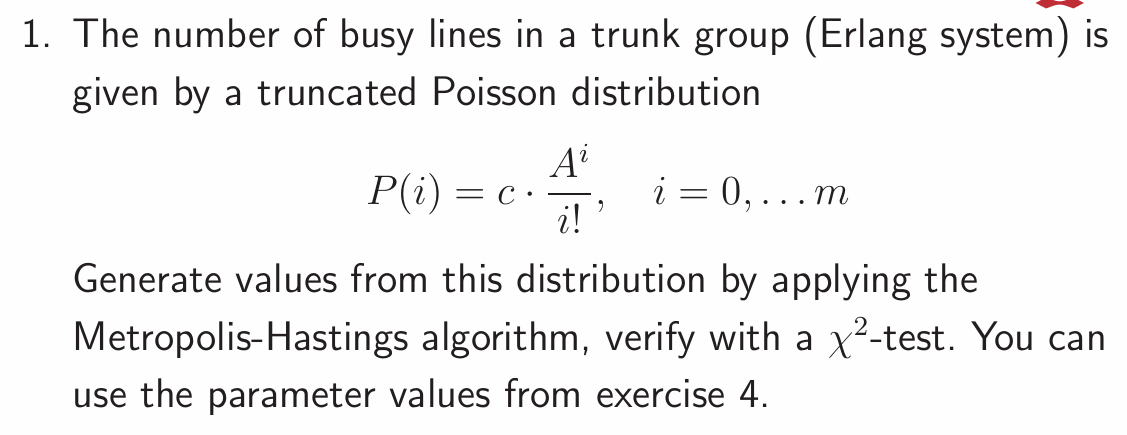

The Metropolis hastings algorithm is defined as: 

## Metropolis-Hastings Algorithm

Let $\pi(x)$ be the unnormalized target density (or mass function) and $q(x' \mid x)$ be the proposal distribution.

---

**Step 1: Initialize**

Choose an arbitrary starting state $x^{(0)}$ such that $\pi(x^{(0)}) > 0$.  
Set $t = 1$.

---

**Step 2: Propose**

Sample a candidate state:
$$x' \sim q(\,\cdot \mid x^{(t-1)}).$$

---

**Step 3: Compute Acceptance Probability**

$$\alpha(x' \mid x^{(t-1)}) = \min\left\{ 1,\; \frac{\pi(x')}{\pi(x^{(t-1)})}\, \frac{q(x^{(t-1)} \mid x')}{q(x' \mid x^{(t-1)})} \right\}.$$

If the proposal is symmetric, i.e. $q(x' \mid x) = q(x \mid x')$, this simplifies to:
$$\alpha(x' \mid x^{(t-1)}) = \min\left\{ 1,\; \frac{\pi(x')}{\pi(x^{(t-1)})} \right\}.$$

---

**Step 4: Accept or Reject**

Draw $u \sim \text{Uniform}(0,1)$.

$$x^{(t)} = 
\begin{cases}
x' & \text{if } u \leq \alpha(x' \mid x^{(t-1)}), \\[6pt]
x^{(t-1)} & \text{otherwise}.
\end{cases}$$

---

**Step 5: Iterate**

Increment $t \leftarrow t + 1$ and return to **Step 2**.



In this case we have the unnormalized distribution: 

$ \pi(i) = \frac{A^i}{i!} $.

In this case a good choice of proposal distribution could be a uniform distribution with support from 1 to m. Since the uniform distribution is symmetric the acceptance probability simplifies to:

$\alpha(j|i) = min\{1,\frac{\pi(j)}{\pi(i)}\}$. 

With this we can now implement the algorithm:

Chi-squared statistic: 14.19, p-value: 0.1643


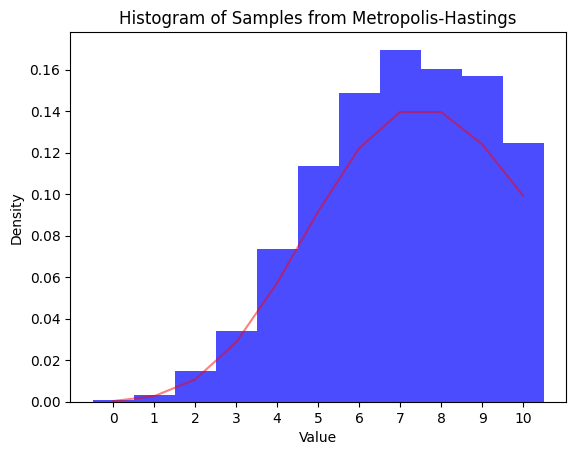

In [21]:
import numpy as np
from math import factorial
import matplotlib.pyplot as plt

np.random.seed(0)

n_samples = 10000
A = 8
m = 10

i = np.random.randint(0, m + 1)
samples = []

for t in range(n_samples):
    j = np.random.randint(0, m + 1)
    
    alpha = min(1, (A**j / factorial(j)) / (A**i / factorial(i)))
    
    if np.random.uniform(0, 1) < alpha:
        i = j
    samples.append(i)

# Compare with true poisson using Chi-squared test
from scipy.stats import chisquare
observed_counts = np.bincount(samples, minlength=m+1)
expected_counts = [n_samples * (A**k / factorial(k)) / sum(A**r / factorial(r) for r in range(m+1)) for k in range(m+1)]
chi2_stat, p_value = chisquare(observed_counts, f_exp=expected_counts)
print(f"Chi-squared statistic: {chi2_stat:.2f}, p-value: {p_value:.4f}")

# Compare with true Poisson distribution
from scipy.stats import poisson
x = np.arange(0, m + 1)
plt.plot(x, poisson.pmf(x, A), alpha=0.5, label='Poisson PMF', color = 'red')
plt.hist(samples, bins=np.arange(m+2)-0.5, density=True, alpha=0.7, color='blue')
plt.title('Histogram of Samples from Metropolis-Hastings')
plt.xlabel('Value')
plt.ylabel('Density')
plt.xticks(range(m+1))
plt.show()
    


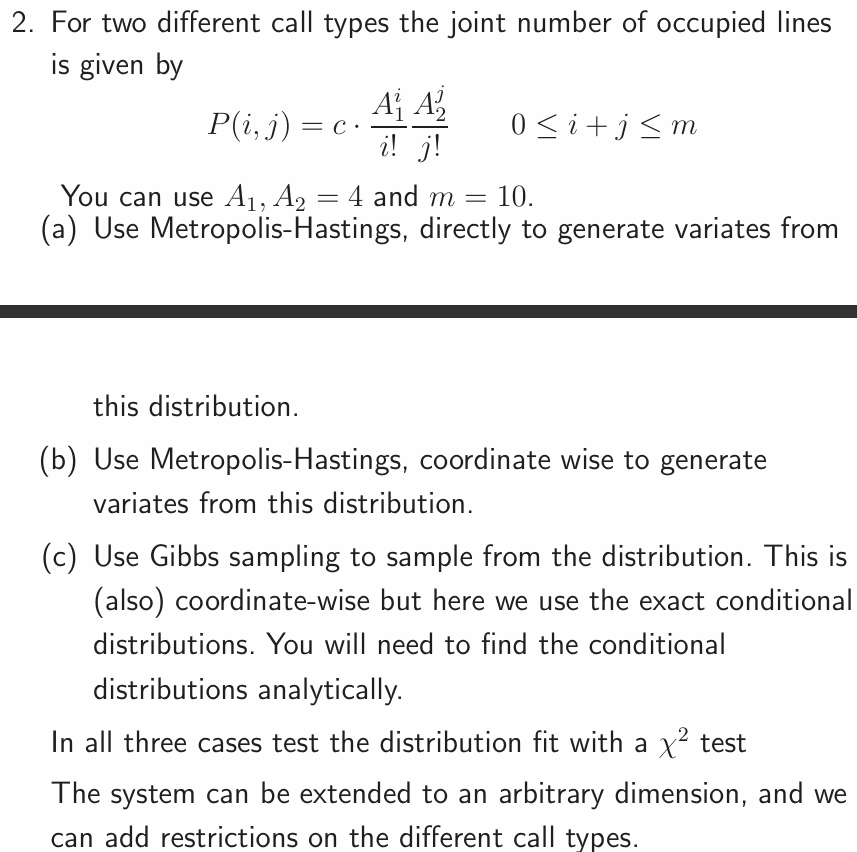

### (a)
Now we have the unnormalized distribution:

$$\pi(i,j) = \frac{A_1^iA_2^j}{i!j!}$$

We perform the same algorithm as before, except now we propose two values $(i,j)$ instead of just one. We will use the same symmetric distribution as before to get: 

$$\alpha = min(1, \frac{A_1^{i´}A_2^{j´}i!j!}{A_1^{i}A_2^{j}i´!j´!})$$

In [4]:
import numpy as np
from scipy import stats
from scipy.special import factorial
import matplotlib.pyplot as plt

# =============================================================================
# Parameters
# =============================================================================
A1 = 4.0
A2 = 4.0
m = 10

# All valid states (i,j) with i,j >= 0 and i+j <= m
states = [(i, j) for i in range(m + 1) for j in range(m + 1 - i)]
n_states = len(states)                     # 66
state_to_idx = {s: idx for idx, s in enumerate(states)}

# Normalization constant: Z = sum_{k=0}^m (A1+A2)^k / k!
Z = sum((A1 + A2) ** k / factorial(k) for k in range(m + 1))
theoretical_probs = np.array([
    (A1 ** i / factorial(i)) * (A2 ** j / factorial(j)) / Z
    for i, j in states
])

# =============================================================================
# Helpers
# =============================================================================
def target_ratio(i_new, j_new, i_old, j_old):
    """pi(i_new,j_new) / pi(i_old,j_old). Returns 0 if invalid."""
    if i_new < 0 or j_new < 0 or i_new + j_new > m:
        return 0.0
    ratio = (A1 ** i_new / factorial(i_new)) * (A2 ** j_new / factorial(j_new))
    ratio /= (A1 ** i_old / factorial(i_old)) * (A2 ** j_old / factorial(j_old))
    return ratio

def sample_truncated_poisson(lam, max_val):
    """Sample Poisson(lam) truncated to {0,...,max_val}."""
    ks = np.arange(max_val + 1)
    probs = lam ** ks / factorial(ks)
    probs /= probs.sum()
    return np.random.choice(ks, p=probs)

# =============================================================================
# (a) Direct Metropolis-Hastings
# =============================================================================
def direct_mh(n_samples, burn_in=5000, thin=5):
    i, j = 0, 0
    samples, n_prop, n_acc = [], 0, 0

    for step in range(burn_in + n_samples * thin):
        direction = np.random.randint(4)
        if direction == 0:    i_prop, j_prop = i + 1, j
        elif direction == 1:  i_prop, j_prop = i - 1, j
        elif direction == 2:  i_prop, j_prop = i, j + 1
        else:                 i_prop, j_prop = i, j - 1

        if i_prop >= 0 and j_prop >= 0 and i_prop + j_prop <= m:
            n_prop += 1
            alpha = min(1.0, target_ratio(i_prop, j_prop, i, j))
            if np.random.rand() < alpha:
                i, j = i_prop, j_prop
                n_acc += 1

        if step >= burn_in and (step - burn_in) % thin == 0:
            samples.append((i, j))

    return np.array(samples), n_acc / n_prop if n_prop else 0

# =============================================================================
# (b) Coordinate-wise Metropolis-Hastings
# =============================================================================
def coordwise_mh(n_samples, burn_in=5000, thin=5):
    i, j = 0, 0
    samples = []
    n_prop = [0, 0]
    n_acc  = [0, 0]

    for step in range(burn_in + n_samples * thin):
        # --- update i (fix j) ---
        delta = 1 if np.random.rand() < 0.5 else -1
        i_prop = i + delta
        if 0 <= i_prop <= m - j:
            n_prop[0] += 1
            alpha = min(1.0, target_ratio(i_prop, j, i, j))
            if np.random.rand() < alpha:
                i = i_prop
                n_acc[0] += 1

        # --- update j (fix i) ---
        delta = 1 if np.random.rand() < 0.5 else -1
        j_prop = j + delta
        if 0 <= j_prop <= m - i:
            n_prop[1] += 1
            alpha = min(1.0, target_ratio(i, j_prop, i, j))
            if np.random.rand() < alpha:
                j = j_prop
                n_acc[1] += 1

        if step >= burn_in and (step - burn_in) % thin == 0:
            samples.append((i, j))

    acc_i = n_acc[0] / n_prop[0] if n_prop[0] else 0
    acc_j = n_acc[1] / n_prop[1] if n_prop[1] else 0
    return np.array(samples), (acc_i, acc_j)

# =============================================================================
# (c) Gibbs Sampling
# =============================================================================
def gibbs_sampler(n_samples, burn_in=5000, thin=5):
    i, j = 0, 0
    samples = []
    for step in range(burn_in + n_samples * thin):
        i = sample_truncated_poisson(A1, m - j)   # i | j
        j = sample_truncated_poisson(A2, m - i)   # j | i
        if step >= burn_in and (step - burn_in) % thin == 0:
            samples.append((i, j))
    return np.array(samples)

# =============================================================================
# Chi-square test (merges low-expectation bins)
# =============================================================================
def chi_square_test(samples, min_expected=5.0):
    n = len(samples)
    counts = np.zeros(n_states)
    for s in samples:
        counts[state_to_idx[(int(s[0]), int(s[1]))]] += 1

    expected = n * theoretical_probs
    merged_obs, merged_exp = [], []
    curr_obs = curr_exp = 0.0

    for obs, exp in zip(counts, expected):
        curr_obs += obs
        curr_exp += exp
        if curr_exp >= min_expected:
            merged_obs.append(curr_obs)
            merged_exp.append(curr_exp)
            curr_obs = curr_exp = 0.0

    if curr_exp > 0:
        if merged_exp:
            merged_obs[-1] += curr_obs
            merged_exp[-1] += curr_exp
        else:
            merged_obs.append(curr_obs)
            merged_exp.append(curr_exp)

    merged_obs = np.array(merged_obs)
    merged_exp = np.array(merged_exp)
    chi2_stat = np.sum((merged_obs - merged_exp) ** 2 / merged_exp)
    df = len(merged_obs) - 1
    p_value = 1 - stats.chi2.cdf(chi2_stat, df)
    return chi2_stat, df, p_value, len(merged_obs)

# =============================================================================
# Run and test
# =============================================================================
np.random.seed(42)
n_samples, burn_in, thin = 20000, 5000, 5

s_direct, acc_direct = direct_mh(n_samples, burn_in, thin)
s_coord,  acc_coord  = coordwise_mh(n_samples, burn_in, thin)
s_gibbs              = gibbs_sampler(n_samples, burn_in, thin)

print(f"Direct MH acceptance rate:      {acc_direct:.4f}")
print(f"Coord-wise MH acceptance: i={acc_coord[0]:.4f}, j={acc_coord[1]:.4f}")

for name, samples in [("Direct MH", s_direct),
                      ("Coordinate-wise MH", s_coord),
                      ("Gibbs Sampling", s_gibbs)]:
    chi2_stat, df, p_val, n_cat = chi_square_test(samples)
    print(f"\n{name}:")
    print(f"  chi2 = {chi2_stat:.3f}, df = {df}, p = {p_val:.4f}")

Direct MH acceptance rate:      0.8222
Coord-wise MH acceptance: i=0.8238, j=0.8258

Direct MH:
  chi2 = 84.156, df = 63, p = 0.0388

Coordinate-wise MH:
  chi2 = 64.391, df = 63, p = 0.4277

Gibbs Sampling:
  chi2 = 61.962, df = 63, p = 0.5133
